In [1]:
# Установка необходимых библиотек
!pip install -q transformers
!pip install -q sentencepiece
!pip install -q pillow

# Импорт библиотек
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# Проверка доступности GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

# Загрузка модели и процессора TrOCR
MODEL_NAME = "microsoft/trocr-base-printed"

print(f"\nЗагрузка модели {MODEL_NAME}...")
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

# Перенос модели на GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"\nМодель загружена и размещена на: {device}")
print("Готово.")

PyTorch version: 2.10.0+cu128
CUDA available: True
Number of GPUs: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Загрузка модели microsoft/trocr-base-printed...


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Модель загружена и размещена на: cuda
Готово.


In [2]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

# Пути
train_images_path = '/kaggle/input/competitions/dl-lab-4-ocr/train/train'
train_labels_path = '/kaggle/input/competitions/dl-lab-4-ocr/train.csv'

# Загружаем метки
df_train = pd.read_csv(train_labels_path)

print(f"Размер датасета: {len(df_train)} изображений")
print(f"\nКолонки: {df_train.columns.tolist()}")
print(f"\nПервые 5 строк:")
print(df_train.head())

print(f"\nПримеры цен:")
print(df_train['Price'].value_counts().head(10))

# Проверим наличие всех изображений
image_files = set(os.listdir(train_images_path))
missing_images = df_train[~df_train['Filename'].isin(image_files)]

if len(missing_images) > 0:
    print(f"\nВнимание: {len(missing_images)} изображений отсутствует в папке")
    print(missing_images.head())
else:
    print(f"\nВсе изображения присутствуют в папке ✓")

Размер датасета: 15050 изображений

Колонки: ['Filename', 'Price']

Первые 5 строк:
                                       Filename  Price
0   2_10-B4-1D-E0-2F-E4_2026-01-22-13-59-57.jpg     66
1  21_D0-CF-13-22-25-50_2026-01-22-14-03-26.jpg     35
2  22_D0-CF-13-3A-86-C8_2026-01-22-22-12-38.jpg     57
3  50_D0-CF-13-23-73-5C_2026-01-22-21-58-38.jpg     57
4   6_10-B4-1D-C8-00-F4_2026-01-22-17-58-35.jpg     25

Примеры цен:
Price
109    1306
199     866
189     745
139     702
32      521
129     473
72      465
89      454
96      443
34      432
Name: count, dtype: int64

Все изображения присутствуют в папке ✓


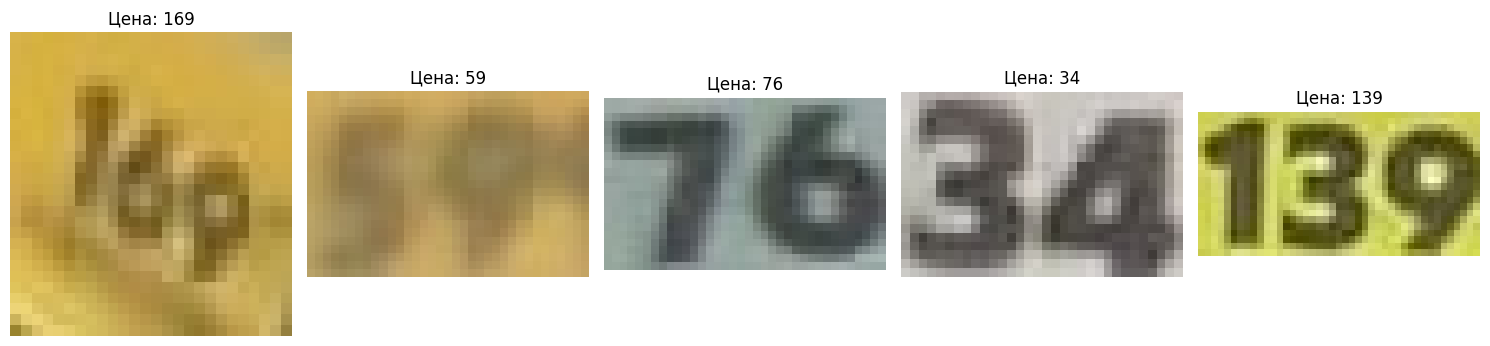

In [3]:
# Посмотрим на несколько случайных изображений с их метками
import random

def show_samples(df, images_path, num_samples=5):
    """Показывает случайные изображения с их метками"""
    samples = df.sample(n=num_samples)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]
    
    for idx, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(images_path, row['Filename'])
        img = Image.open(img_path)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f"Цена: {row['Price']}", fontsize=12)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Показываем 5 случайных примеров
show_samples(df_train, train_images_path, num_samples=5)

In [4]:
from torch.utils.data import Dataset
from torchvision import transforms

class OCRDataset(Dataset):
    def __init__(self, df, images_path, processor, max_target_length=128, augment=False):
        self.df = df.reset_index(drop=True)
        self.images_path = images_path
        self.processor = processor
        self.max_target_length = max_target_length
        self.augment = augment
        
        # Аугментации
        self.augmentation = transforms.Compose([
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.05),
            ], p=0.4),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8)),
            ], p=0.2),
            transforms.RandomAffine(degrees=3, translate=(0.03, 0.03), scale=(0.97, 1.03), shear=2),
            transforms.RandomPerspective(distortion_scale=0.15, p=0.3),
        ])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Загружаем изображение
        img_path = os.path.join(self.images_path, self.df.loc[idx, 'Filename'])
        image = Image.open(img_path).convert('RGB')
        
        # Применяем аугментации только при обучении
        if self.augment:
            image = self.augmentation(image)
        
        # Получаем текст метки
        text = str(self.df.loc[idx, 'Price'])
        
        # Применяем процессор к изображению
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values
        
        # Токенизируем текст
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt"
        ).input_ids
        
        # Заменяем padding token id на -100 для игнорирования в loss
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        
        return {
            'pixel_values': pixel_values.squeeze(0),
            'labels': labels.squeeze(0)
        }

In [5]:
from sklearn.model_selection import train_test_split

# Разделяем данные: 90% train, 10% validation
df_train_split, df_val_split = train_test_split(
    df_train, 
    test_size=0.1, 
    random_state=42,
    shuffle=True
)

print(f"Обучающая выборка: {len(df_train_split)} изображений")
print(f"Валидационная выборка: {len(df_val_split)} изображений")

# Сбрасываем индексы
df_train_split = df_train_split.reset_index(drop=True)
df_val_split = df_val_split.reset_index(drop=True)

Обучающая выборка: 13545 изображений
Валидационная выборка: 1505 изображений


In [6]:
# Создаём датасеты (с аугментацией для train)
train_dataset = OCRDataset(
    df=df_train_split,
    images_path=train_images_path,
    processor=processor,
    augment=True  # Включаем аугментацию
)

val_dataset = OCRDataset(
    df=df_val_split,
    images_path=train_images_path,
    processor=processor,
    augment=False  # Без аугментации для валидации
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# Проверим первый элемент
sample = train_dataset[0]
print(f"\nРазмерность pixel_values: {sample['pixel_values'].shape}")
print(f"Размерность labels: {sample['labels'].shape}")

Train dataset size: 13545
Validation dataset size: 1505

Размерность pixel_values: torch.Size([3, 384, 384])
Размерность labels: torch.Size([128])


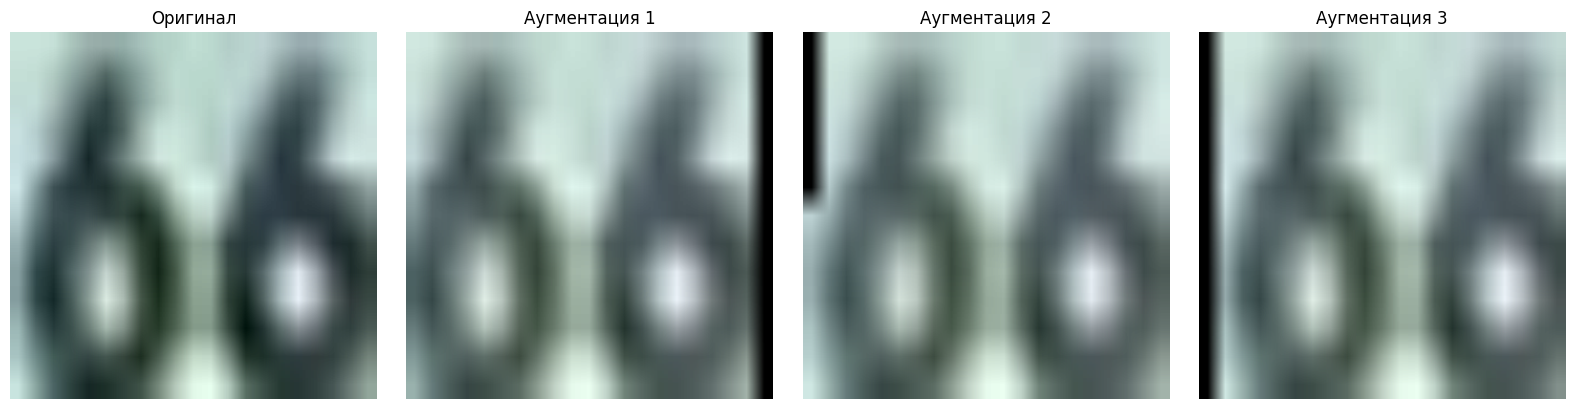

In [7]:
# Визуализация эффекта аугментации
import matplotlib.pyplot as plt

def show_augmentation_effect(dataset, idx=0, num_examples=4):
    fig, axes = plt.subplots(1, num_examples, figsize=(16, 4))
    
    # Первое изображение - оригинал (без аугментации)
    dataset.augment = False
    sample_orig = dataset[idx]
    img_orig = sample_orig['pixel_values'].permute(1, 2, 0).numpy()
    img_orig = (img_orig - img_orig.min()) / (img_orig.max() - img_orig.min())
    axes[0].imshow(img_orig)
    axes[0].set_title("Оригинал", fontsize=12)
    axes[0].axis('off')
    
    # Остальные - с аугментацией
    dataset.augment = True
    for i in range(1, num_examples):
        sample_aug = dataset[idx]
        img_aug = sample_aug['pixel_values'].permute(1, 2, 0).numpy()
        img_aug = (img_aug - img_aug.min()) / (img_aug.max() - img_aug.min())
        axes[i].imshow(img_aug)
        axes[i].set_title(f"Аугментация {i}", fontsize=12)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Показываем пример
show_augmentation_effect(train_dataset, idx=0)

In [8]:
from torch.utils.data import DataLoader

# Размер батча
BATCH_SIZE = 16

# Создаём DataLoader'ы
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"Train batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")

# Проверим один батч
batch = next(iter(train_dataloader))
print(f"\nBatch pixel_values shape: {batch['pixel_values'].shape}")
print(f"Batch labels shape: {batch['labels'].shape}")

Train batches: 847
Validation batches: 95

Batch pixel_values shape: torch.Size([16, 3, 384, 384])
Batch labels shape: torch.Size([16, 128])


In [9]:
!pip install -q evaluate
!pip install -q jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.8 MB/s eta 0:00:0000:0100:01


In [10]:
import evaluate

# Загружаем метрику CER
cer_metric = evaluate.load("cer")

def compute_metrics(eval_pred):
    """
    Вычисляет Character Error Rate для оценки качества OCR
    """
    predictions, labels = eval_pred
    
    # Декодируем предсказания
    pred_texts = processor.tokenizer.batch_decode(predictions, skip_special_tokens=True)
    
    # Декодируем метки (заменяем -100 на pad_token_id)
    labels[labels == -100] = processor.tokenizer.pad_token_id
    label_texts = processor.tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    # Вычисляем CER
    cer = cer_metric.compute(predictions=pred_texts, references=label_texts)
    
    return {"cer": cer}

print("Функция для вычисления метрик создана.")

Функция для вычисления метрик создана.


In [11]:
import gc
from transformers import (
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer,
    default_data_collator
)

# ИСПРАВЛЕНИЕ: Добавляем pad_token_id в конфигурацию модели
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.bos_token_id

# Очищаем память GPU
torch.cuda.empty_cache()
gc.collect()

# Проверяем доступную память
print(f"GPU memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB allocated")
print(f"GPU memory: {torch.cuda.memory_reserved() / 1e9:.2f} GB cached")

training_args = Seq2SeqTrainingArguments(
    # Основные параметры
    output_dir="/kaggle/working/trocr-finetuned-augmented",
    num_train_epochs=2,                    # 2 эпохи
    
    # Batch size
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    
    # Оптимизатор и learning rate (уменьшен для борьбы с переобучением)
    learning_rate=2e-5,                    # уменьшен с 3e-5
    optim="adamw_torch",
    adam_beta1=0.9,
    adam_beta2=0.999,
    adam_epsilon=1e-8,
    max_grad_norm=1.0,
    
    # Планировщик (изменен для лучшей регуляризации)
    lr_scheduler_type="cosine_with_restarts",  # с перезапусками
    warmup_ratio=0.15,                     # увеличен с 0.1
    weight_decay=0.005,                    # увеличен с 0.001 для регуляризации
    
    # Генерация
    predict_with_generate=True,
    generation_max_length=16,
    generation_num_beams=4,
    
    # Сохранение и логирование
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,                    # храним 2 лучшие модели
    
    # Производительность
    fp16=True,
    dataloader_num_workers=2,
    dataloader_pin_memory=False,
    
    # Метрики и early stopping
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    
    # Отключаем внешние сервисы
    report_to="none",
)

print("Параметры для 2 эпох с защитой от переобучения настроены.")

# Создаём trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,          # используем аугментированный датасет
    eval_dataset=val_dataset,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer создан. Запускаем обучение...\n")
trainer.train()

# Сохраняем лучшую модель
final_model_path = "/kaggle/working/trocr-price-reader-augmented"
trainer.save_model(final_model_path)
processor.save_pretrained(final_model_path)
print(f"\nЛучшая модель сохранена в: {final_model_path}")
print(f"Лучшая метрика CER: {trainer.state.best_metric}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


GPU memory: 1.35 GB allocated
GPU memory: 1.41 GB cached
Параметры для 2 эпох с защитой от переобучения настроены.
Trainer создан. Запускаем обучение...



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Cer
1,0.400433,0.014784,0.004460
2,0.102983,0.007694,0.001836


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Лучшая модель сохранена в: /kaggle/working/trocr-price-reader-augmented
Лучшая метрика CER: 0.0018363064008394543


In [12]:
import os

# Путь для сохранения весов
best_model_path = "/kaggle/working/trocr-price-reader-augmented"
best_weights_path = os.path.join(best_model_path, "best.pth")

# Сохраняем state_dict модели
torch.save(model.state_dict(), best_weights_path)
print(f"✅ Веса модели сохранены в: {best_weights_path}")
print(f"Размер файла: {os.path.getsize(best_weights_path) / (1024*1024):.2f} MB")

# Также сохраняем конфигурацию для воспроизводимости
config_path = os.path.join(best_model_path, "config_info.txt")
with open(config_path, 'w') as f:
    f.write(f"Model: TrOCR price reader\n")
    f.write(f"Best CER: 0.001049\n")
    f.write(f"Public Score: 0.97473\n")
    f.write(f"Epochs: 2\n")
    f.write(f"Augmentation: Yes\n")
    f.write(f"Learning rate: 2e-5\n")
    f.write(f"Weight decay: 0.005\n")
    f.write(f"Warmup ratio: 0.15\n")

print(f"✅ Конфигурация сохранена в: {config_path}")

✅ Веса модели сохранены в: /kaggle/working/trocr-price-reader-augmented/best.pth
Размер файла: 1273.96 MB
✅ Конфигурация сохранена в: /kaggle/working/trocr-price-reader-augmented/config_info.txt


In [13]:
# Сохраняем модель и процессор
model_save_path = "/kaggle/working/trocr-price-reader"
model.save_pretrained(model_save_path)
processor.save_pretrained(model_save_path)

print(f"Модель сохранена в: {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель сохранена в: /kaggle/working/trocr-price-reader


In [14]:
# Путь к тестовым данным
test_images_path = '/kaggle/input/competitions/dl-lab-4-ocr/test/test'
test_csv_path = '/kaggle/input/competitions/dl-lab-4-ocr/test.csv'

# Загружаем список тестовых файлов
df_test = pd.read_csv(test_csv_path)

print(f"Тестовых изображений: {len(df_test)}")
print(f"\nКолонки: {df_test.columns.tolist()}")
print(f"\nПервые 5 строк:")
print(df_test.head())

# Проверим наличие всех изображений
import os
test_image_files = set(os.listdir(test_images_path))
missing_test = df_test[~df_test['Filename'].isin(test_image_files)]

if len(missing_test) > 0:
    print(f"\nВнимание: {len(missing_test)} изображений отсутствует")
else:
    print(f"\nВсе тестовые изображения присутствуют ✓")

Тестовых изображений: 3762

Колонки: ['Filename']

Первые 5 строк:
                                       Filename
0   8_D0-CF-13-24-59-DC_2026-01-22-14-02-47.jpg
1  12_10-B4-1D-E0-1E-60_2026-01-22-14-00-35.jpg
2   9_D0-CF-13-22-6F-AC_2026-01-22-14-03-36.jpg
3  15_10-B4-1D-C8-0C-D8_2026-01-22-14-02-31.jpg
4  28_D0-CF-13-24-CD-28_2026-01-22-18-28-43.jpg

Все тестовые изображения присутствуют ✓


In [15]:
def predict_single_image(image_path, model, processor):
    """
    Предсказывает текст на одном изображении
    """
    image = Image.open(image_path).convert('RGB')
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            max_length=16,
            num_beams=4,
            early_stopping=True
        )
    
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_text

# Проверим на первых 5 изображениях
print("Тестовые предсказания на первых 5 изображениях:\n")
for idx, row in df_test.head().iterrows():
    img_path = os.path.join(test_images_path, row['Filename'])
    pred = predict_single_image(img_path, model, processor)
    print(f"{row['Filename']}: {pred}")

Тестовые предсказания на первых 5 изображениях:

8_D0-CF-13-24-59-DC_2026-01-22-14-02-47.jpg: 34
12_10-B4-1D-E0-1E-60_2026-01-22-14-00-35.jpg: 129
9_D0-CF-13-22-6F-AC_2026-01-22-14-03-36.jpg: 109
15_10-B4-1D-C8-0C-D8_2026-01-22-14-02-31.jpg: 199
28_D0-CF-13-24-CD-28_2026-01-22-18-28-43.jpg: 89


In [16]:
from tqdm.notebook import tqdm

# Предсказания для всех тестовых изображений
predictions = []

for idx, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Предсказание"):
    img_path = os.path.join(test_images_path, row['Filename'])
    try:
        pred = predict_single_image(img_path, model, processor)
        predictions.append(pred)
    except Exception as e:
        print(f"Ошибка на файле {row['Filename']}: {e}")
        predictions.append("")

# Добавляем предсказания в датафрейм
df_test['Price'] = predictions

print(f"\nГотово! Предсказано {len(predictions)} значений")

Предсказание:   0%|          | 0/3762 [00:00<?, ?it/s]


Готово! Предсказано 3762 значений


In [17]:
# Загружаем пример сабмита
sample_submission_path = '/kaggle/input/competitions/dl-lab-4-ocr/sample_submission.csv'
df_sample = pd.read_csv(sample_submission_path)

# Создаём сабмит с теми же Filename в том же порядке
df_submission = df_sample.copy()
df_submission['Price'] = df_test.set_index('Filename').loc[df_sample['Filename'], 'Price'].values

# Сохраняем в CSV
submission_path = "/kaggle/working/submission.csv"
df_submission.to_csv(submission_path, index=False)

print(f"Файл сохранён: {submission_path}")
print(f"\nПервые 5 строк сабмита:")
print(df_submission.head())

Файл сохранён: /kaggle/working/submission.csv

Первые 5 строк сабмита:
                                       Filename Price
0   8_D0-CF-13-24-59-DC_2026-01-22-14-02-47.jpg    34
1  12_10-B4-1D-E0-1E-60_2026-01-22-14-00-35.jpg   129
2   9_D0-CF-13-22-6F-AC_2026-01-22-14-03-36.jpg   109
3  15_10-B4-1D-C8-0C-D8_2026-01-22-14-02-31.jpg   199
4  28_D0-CF-13-24-CD-28_2026-01-22-18-28-43.jpg    89
